# Import

In [1]:
import os
import gc
import random
from tqdm import tqdm, trange

import numpy as np
import pandas as pd
from pandas import DataFrame
import matplotlib.pyplot as plt
from scipy import signal

import torch
from torch import tensor
from torch.optim import RMSprop, Adam, NAdam, SGD, Adamax, Adadelta, AdamW, LBFGS, Adagrad
from torch.utils.data import random_split, DataLoader
from torch.nn.functional import normalize
import torch.nn.functional as F
from datasets import Dataset, DatasetDict, load_from_disk

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

import shap
import pickle

from IPython.display import clear_output, Image as IPImage, display
import time

# Config

In [2]:
base = "Exploring-the-Relationship-between-Brain-Hemisphere-States-and-Frequency-Bands-through-Deep-Learning-main/"
INTENSITIES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

DATA_DIR = 'Datasets/'
CP_DIR = 'Checkpoints/'
LOG_DIR = 'Log/'


torch.cuda.empty_cache()
gc.collect()

from torch import nn

class Config:
    EXPERIMETS = datasets = [
        "Mona Lisa",
        "Necker cube"
        ]
    RHYTHMS = signal_fiq = [
        'alpha',
        'beta',
        'delta',
        'gamma',
        'theta'
        ]
    MODELS = [
        'Big',
        'Small',
        'CNN'
        ]
    OPTIMIZER_LIST = [
        'Adadelta',
        'Adagrad',
        'Adam',
        'Adamax',
        'AdamW',
        'NAdam',
        'RMSprop',
        'SGD'
        ]
    signal_name = signal_fiq
    batch_size = 100
    threshold = 0.001
    seed = 42
    n_folds = 10
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # device = torch.device('cpu')
    epochs = 200
    in_features = 15000
    out_features  = 6400
    # in_features = 8500
    # out_features  = 42
    activation=nn.ReLU()
    loss_func = nn.CrossEntropyLoss()
    lr_patience = 5
    lr = 1e-5
    save_best_model = True

print(Config.device)

def set_seed(seed = 42):
    torch.initial_seed() % 2**32
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(False)
    gseed = torch.Generator().manual_seed(seed)
    return gseed

set_seed(Config.seed)

cuda


# Robiul preparation

In [ ]:
class EEG:
    def __init__(self, participant,dataset):

        self.int = {}
        self.delta = {}
        self.theta = {}
        self.alpha = {}
        self.beta = {}
        self.gamma = {}

        if dataset == "Mona Lisa":
            Dname = "/Figs for spectra"
            var1 = "/Backgr_int_"
            var2 = ".dat"
        else:
            Dname = "/Cubes for spectra"
            var1 = "/Backgr_int_"
            var2 = "_type_0.4.dat"

        for intensity in INTENSITIES:
            S = os.path.join(base, "Participant " + str(participant) + Dname + var1 + str(intensity) + var2)
            I = intensity
            self.int[I] = np.loadtxt(S)
            delta_signal = np.empty(self.int[I].shape)
            theta_signal =  np.empty(self.int[I].shape)
            alpha_signal = np.empty(self.int[I].shape)
            beta_signal = np.empty(self.int[I].shape)
            gamma_signal = np.empty(self.int[I].shape)

            for c in range(self.int[I].shape[1]):
                delta_signal[:,c], theta_signal[:,c],alpha_signal[:, c], beta_signal[:, c],gamma_signal[:,c] = self.fir_filtering(I, c)
            self.delta[I] = delta_signal
            self.theta[I] = theta_signal
            self.alpha[I] = alpha_signal
            self.beta[I] = beta_signal 
            self.gamma[I] = gamma_signal

    def fir_filtering(self, I, c):
        filter_delta = signal.firwin(400, [1.0, 4.0], pass_zero=False, fs=250)
        filter_theta = signal.firwin(400, [5.0, 8.0], pass_zero=False, fs=250)
        filter_alpha = signal.firwin(400, [8.0, 12.0], pass_zero=False, fs=250)
        filter_beta = signal.firwin(400, [13.0, 30.0], pass_zero=False, fs=250)
        filter_gamma = signal.firwin(400, [31.0, 45.0], pass_zero=False, fs=250)
        res_delta = signal.convolve(self.int[I][:, c], filter_delta, mode='same')
        res_theta = signal.convolve(self.int[I][:, c], filter_theta, mode='same')
        res_alpha = signal.convolve(self.int[I][:, c], filter_alpha, mode='same')
        res_beta = signal.convolve(self.int[I][:, c], filter_beta, mode='same')
        res_gamma = signal.convolve(self.int[I][:, c], filter_gamma, mode='same')
        
        return res_delta,res_theta, res_alpha,res_beta,res_gamma 

In [ ]:
Intencity = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
base = "/mnt/z/Robiul/Data_sets_Encephalan/"
file_path = os.path.join(base, "Channels.dat")
df_channels = pd.read_csv(file_path, header=None, sep='.')
channel_names = df_channels.iloc[:, -1:].values.flatten()

def convart_sin_fiq(fiq):
  if fiq == 'delta':
    return 1
  elif fiq == 'theta':
    return 2
  elif fiq == 'alpha':
    return 3
  elif fiq =='beta': 
    return 4
  elif fiq == 'gamma':
    return 5

def createdataframe(user,dataset,signal_fiq):
    global Intencity,channel_names
    tem_signal = []
    eeg_person = EEG(user,dataset)
    for i in Intencity:
        for ch in range(0,31):
            tem = [dataset,ch,channel_names[ch],convart_sin_fiq(signal_fiq),signal_fiq,i,user]
            # tem = [channel_names[ch]]
            S = 'tem_signal.append(np.append(tem, eeg_person.'+signal_fiq+'.get(i)[:,ch][0:15000]))'
            eval(S)
    
           
    tem_dataframe = pd.DataFrame(tem_signal)

    colunm = [] 

    colunm.append("Dataset")
    colunm.append("channel")
    colunm.append("Channel_Name")
    colunm.append("band")
    colunm.append("frequency")
    colunm.append("Intencity")
    colunm.append("participant")

    for col in range(0,15000):
      S = 'Time'+str(col)
      colunm.append(S)    
    
    
    
    tem_dataframe.columns  = colunm 
    return tem_dataframe

# Dataset

In [ ]:
df = DataFrame()

for experiment in Config.EXPERIMETS:
    for rhythm in Config.RHYTHMS:
        participants = trange(1, 11, leave=True)
        for user in participants:
            df = pd.concat([df, createdataframe(user, experiment, rhythm)], ignore_index=True)
            participants.set_postfix(rhythm=rhythm, user=user, counts=len(df),  experiment=experiment, refresh=True)
df            

In [ ]:
dataset = DatasetDict()
splits = df['frequency'].unique()

for split in tqdm(splits):
    dataset[split] = Dataset.from_pandas(df[df['frequency'] == split], split=split)

print(dataset)

In [ ]:
dataset.save_to_disk(DATA_DIR)

## Spectrogram

In [ ]:
dataset = load_from_disk(DATA_DIR)

df = dataset[Config.RHYTHMS[0]].to_pandas()
tdf = df.iloc[:, 7:]
tdf.drop(columns='__index_level_0__', inplace=True)
tdf = tdf.astype(float)

In [ ]:
data = tdf.iloc[0].values
fig, (ax1) = plt.subplots(nrows=1, sharex=True)

plt.specgram(data.T, Fs=250, cmap="viridis")
plt.title('Spectrogram Alpha')
plt.xlabel("DATA")
plt.ylabel("TIME")
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.show()
plt.plot(data)

## Load

In [3]:
DATASET = load_from_disk(dataset_path=DATA_DIR)

In [4]:
from sklearn.calibration import LabelEncoder
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset
from datasets import load_from_disk, Dataset
from torch.utils.data.dataset import Dataset


class CustomDataset(Dataset):
    def __init__(self, experiment: str, signal: str, dataset = DATASET, normalize = None, batch_size=Config.batch_size):

        super(CustomDataset, self).__init__()
        self.batch_size = batch_size
        try:
            self.dataset = dataset[signal].remove_columns('__index_level_0__')
        except ValueError:
            self.dataset = dataset[signal]
        self.dataframe = self.dataset.to_pandas()
        self.dataframe = self.dataframe[self.dataframe['Dataset'] == experiment]
        self.index_list = self.dataframe.index.to_list()
        self.normalize = normalize


        self.X_df = self.X_df()
        self.y_df = self.y_df()

        self.generator_seed = set_seed(Config.seed)

        self.train, self.val, self.test = self.train_val_test()
        self.df_train, self.df_test = self.df_shap()

        self.train_dataloader = self.train_dataloader()
        self.val_dataloader = self.val_dataloader()
        self.test_dataloader = self.test_dataloader()

    def __len__(self):
        return len(self.dataframe)
    
    def shape(self):
        return self.tensor.shape
    
    def size(self) -> int:
        return super().__sizeof__(self.__len__(), *self.__getitem__(0)[0].shape)
   
    def X_df(self):
        X_df = self.dataframe.iloc[:, 7:]
        X_df = X_df.astype(float)
        return X_df
    
    def y_df(self):
        label = self.dataframe['Channel_Name'].map(lambda x: np.int8(0) if 'A1' in x else np.int8(1))
        return label
    
    def df_shap(self):
        self.dataframe['Stratify'] = self.dataframe['Channel_Name'].astype(str) + '_' + self.dataframe['Intencity'].astype(str)

        train_x, val_x, train_y, val_y, train_idx, val_idx = train_test_split(self.X_df, self.y_df, self.index_list,
                                            test_size=0.2,
                                            shuffle=True,
                                            stratify=self.dataframe['Stratify'],
                                            ) 
        val_x, test_x, val_y, test_y, val_idx, test_idx = train_test_split(val_x, val_y, val_idx,
                                            test_size=0.5,
                                            shuffle=True,
                                            stratify=val_y,
                                            )
        
        # train_x = torch.tensor(train_x.values, dtype=torch.float)
        # val_x = torch.tensor(val_x.values, dtype=torch.float)
        # test_x = torch.tensor(test_x.values, dtype=torch.float)

        # train_idx = torch.tensor(train_idx, dtype=torch.int)
        # val_idx = torch.tensor(val_idx, dtype=torch.int)
        # test_idx = torch.tensor(test_idx, dtype=torch.int)


        # train_x_y = TensorDataset(train_x, torch.tensor(train_y.values, dtype=torch.long), train_idx)
        # val_x_y = TensorDataset(val_x, torch.tensor(val_y.values, dtype=torch.long), val_idx)
        # test_x_y = TensorDataset(test_x, torch.tensor(test_y.values, dtype=torch.long), test_idx)

        return train_x, test_x    
    
    def train_val_test(self):
        self.dataframe['Stratify'] = self.dataframe['Channel_Name'].astype(str) + '_' + self.dataframe['Intencity'].astype(str)

        train_x, val_x, train_y, val_y, train_idx, val_idx = train_test_split(self.X_df, self.y_df, self.index_list,
                                            test_size=0.2,
                                            shuffle=True,
                                            stratify=self.dataframe['Stratify'],
                                            ) 
        val_x, test_x, val_y, test_y, val_idx, test_idx = train_test_split(val_x, val_y, val_idx,
                                            test_size=0.5,
                                            shuffle=True,
                                            stratify=val_y,
                                            )
        
        train_x = torch.tensor(train_x.values, dtype=torch.float)
        val_x = torch.tensor(val_x.values, dtype=torch.float)
        test_x = torch.tensor(test_x.values, dtype=torch.float)

        train_idx = torch.tensor(train_idx, dtype=torch.int)
        val_idx = torch.tensor(val_idx, dtype=torch.int)
        test_idx = torch.tensor(test_idx, dtype=torch.int)


        train_x_y = TensorDataset(train_x, torch.tensor(train_y.values, dtype=torch.long), train_idx)
        val_x_y = TensorDataset(val_x, torch.tensor(val_y.values, dtype=torch.long), val_idx)
        test_x_y = TensorDataset(test_x, torch.tensor(test_y.values, dtype=torch.long), test_idx)

        return train_x_y, val_x_y, test_x_y
    
    def train_dataloader(self):
        train_dataloader = DataLoader(self.train, batch_size=self.batch_size, shuffle=True, num_workers=20, drop_last=True, generator=self.generator_seed, pin_memory_device='cuda', pin_memory=True)
        return train_dataloader
    
    def val_dataloader(self):
        val_dataloader = DataLoader(self.val, batch_size=self.batch_size, shuffle=False, num_workers=20, drop_last=True, generator=self.generator_seed, pin_memory_device='cuda', pin_memory=True)
        return val_dataloader
    
    def test_dataloader(self):
        test_dataloader = DataLoader(self.test, batch_size=self.batch_size, shuffle=False, num_workers=20, drop_last=True, generator=self.generator_seed, pin_memory_device='cuda', pin_memory=True)
        return test_dataloader

# Model

In [5]:
import os
import random
import numpy as np
import torch.nn as nn

class RobiulModel(nn.Module):

    def __init__(self,
                model_name = 'Small',
                experiment = Config.EXPERIMETS[0],
                rhythm = Config.RHYTHMS[0],
                optimizer = Config.OPTIMIZER_LIST[0],
                in_features = Config.in_features,
                out_features = Config.out_features,
                lr = Config.lr,
                batch_size = Config.batch_size,
                shap_mode = False,
                dataset=DATASET,
                ):
        
        super(RobiulModel, self).__init__()
        gc.collect()
        if Config.device == 'cuda': torch.cuda.empty_cache()
        self.shap_mode = shap_mode
        self.dataset =  CustomDataset(experiment=experiment, signal=rhythm, dataset=dataset, batch_size=batch_size)
        self.config(in_features, out_features)
        self.activation = Config.activation
        self.model_name = model_name
        self.experiment = experiment
        self.rhythm = rhythm
        self.optimizer = optimizer
        self.lr = lr
        self.batch_size = batch_size
        self.best_epoch = 0
        self.best_val_acc = 0
        self.best_test_acc = 0
        self.threshold = 0.5
        self.train_loss = []
        self.train_acc = []
        self.val_loss = []
        self.val_acc = []
        self.epochs = Config.epochs
        self.lr_hist = []
        self.best_loss = None
        self.count = 0
        self.test_loss = []
        self.test_acc = []

        self.X_cr = []
        self.roc_lr_probs = []
    

        if model_name == 'Big':
            self.lr = 1e-2
            self.linear_stack = nn.Sequential(
                nn.Linear(self.in_features, self.out_features, bias=False),
                self.activation,
                nn.BatchNorm1d(self.out_features),
                nn.Linear(self.out_features, 1000, bias=False),
                self.activation,
                nn.BatchNorm1d(1000),
                nn.Linear(1000, 500, bias=False),
                self.activation,
                nn.BatchNorm1d(500),
                nn.Linear(500, 200, bias=False),
                self.activation,
                nn.BatchNorm1d(200),
                nn.Linear(200, 100, bias=False),
                self.activation,
                nn.BatchNorm1d(100),
                nn.Linear(100, 50, bias=False),
                self.activation,
                nn.BatchNorm1d(50),
                nn.Linear(50, 25, bias=False),
                self.activation,
                nn.BatchNorm1d(25),
                nn.Linear(25, 15, bias=False),
                self.activation,
                nn.BatchNorm1d(15),
                nn.Linear(15, 10, bias=False),
                self.activation,
                nn.BatchNorm1d(10),
                nn.Linear(10, 1, bias=False),
                # self.activation,
                # nn.BatchNorm1d(1),
                nn.Sigmoid(),
            )
        elif model_name == 'Small':
            self.lr = 1e-5
            self.linear_stack = nn.Sequential(
                nn.Linear(self.in_features, self.out_features, bias=False),
                self.activation,
                nn.BatchNorm1d(self.out_features),
                nn.Linear(self.out_features, 10, bias=False),
                self.activation,
                nn.BatchNorm1d(10),
                nn.Linear(10, 1, bias=False),
                nn.Sigmoid(),
                
            )            
        elif model_name == 'CNN':
            self.lr = 1e-3
            self.cnn = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 64, kernel_size=3, stride=1, padding=1),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.MaxPool1d(2),
            )

            self.cnn_linear = nn.Sequential(
                nn.Linear(Config.in_features, self.batch_size),
                nn.LeakyReLU(inplace=True),
                nn.Linear(self.batch_size, 2),
            )

        self = self.to(Config.device)
        self.settings()        
        self.metrics_dir = f'{LOG_DIR}{self.model_name}_{self.experiment.replace(' ', '_')}_{self.rhythm}_{self.optimizer.__class__.__name__}/'        

    
    def forward(self, x):
        if self.model_name == 'CNN':
            if self.shap_mode:
                x = torch.tensor(data=x.to_numpy(), dtype=torch.float).to(torch.device(Config.device))
            x = x.unsqueeze(1)
            x = self.cnn(x)
            x = x.view(x.size(0), -1)
            x = self.cnn_linear(x)
            return x
        else:
            if self.shap_mode:
                x = torch.tensor(data=x.to_numpy(), dtype=torch.float).to(torch.device(Config.device))
            logits = self.linear_stack(x)
            logits = logits.squeeze()
            return logits
    
    def config(self,
        in_features = Config.in_features,
        out_features = Config.out_features):
        self.in_features = in_features
        self.out_features = out_features
    
    def settings(self):
        self.loss_func = Config.loss_func
        
        if self.optimizer == 'NAdam':
            self.optimizer = NAdam(self.parameters(), lr=self.lr)
        elif self.optimizer == 'SGD':
            self.optimizer = SGD(self.parameters(), lr=self.lr)
        elif self.optimizer == 'Adam':
            self.optimizer = Adam(self.parameters(), lr=self.lr)
        elif self.optimizer == 'AdamW':
            self.optimizer = Adam(self.parameters(), lr=self.lr)
        elif self.optimizer == 'RMSprop':
            self.optimizer = RMSprop(self.parameters(), lr=self.lr)
        elif self.optimizer == 'Adamax':
            self.optimizer = Adamax(self.parameters(), lr=self.lr)  
        elif self.optimizer == 'LBFGS':
            self.optimizer = LBFGS(self.parameters(), lr=self.lr)
        elif self.optimizer == 'Adadelta':
            self.optimizer = Adadelta(self.parameters(), lr=self.lr)
        elif self.optimizer == 'Adagrad':
            self.optimizer = Adagrad(self.parameters(), lr=self.lr)            

        self.lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=self.optimizer,
                                                                mode='min',
                                                                patience=Config.lr_patience,
                                                                # threshold=Config.threshold,
                                                                threshold_mode='rel',
                                                                # cooldown=0,
                                                                min_lr=0,
                                                                # eps=1e-8,
                                                                )
        
    def fit(self):   
        self.start_time = time.time()
        for epoch in range(self.epochs):
            train_loop = tqdm(self.dataset.train_dataloader, leave=False)
            train_loss = 0.0
            correct = 0
            self.train()
            for batch in train_loop:
                self.optimizer.zero_grad()
                X = batch[0].to(Config.device)
                targets = batch[1].to(Config.device)
                pred = self(X)

                if self.model_name == 'CNN':
                    loss = self.loss_func(pred, targets.to(torch.long))
                    pred = pred.argmax(dim=1)
                    predicted_classes = (pred >= self.threshold).to(torch.int)                
                else:
                    targets = targets.to(torch.float) 
                    loss = self.loss_func(pred, targets)    
                    predicted_classes = (pred >= self.threshold).to(torch.int)

                loss.backward()
                self.optimizer.step()
                train_loss += loss.item() * targets.size(0) 
                mean_train_loss = train_loss / len(self.dataset.train_dataloader.sampler)
                train_loop.set_description(f'Epoch: [{epoch+1}/{self.epochs}]')
                correct += torch.eq(predicted_classes, targets).sum().item()
                running_train_acc = correct / len(self.dataset.train)

            self.train_loss.append(mean_train_loss)
            self.train_acc.append(running_train_acc)

            self.eval()
            val_loss = 0.0
            with torch.no_grad():
                correct = 0
                for batch in self.dataset.val_dataloader:
                    X = batch[0].to(Config.device)
                    targets = batch[1].to(Config.device)
                    pred = self(X)

                    if self.model_name == 'CNN':
                        loss = self.loss_func(pred, targets.to(torch.long))
                        pred = pred.argmax(dim=1)
                        predicted_classes = (pred >= self.threshold).to(torch.int)  
                    else:
                        loss = self.loss_func(pred.to(torch.float), targets.to(torch.float))
                        predicted_classes = (pred >= self.threshold).to(torch.int)

                    val_loss += loss.item() * targets.size(0)
                    val_size = len(self.dataset.val_dataloader.sampler)
                    mean_val_loss = val_loss / val_size 

                    correct += torch.eq(predicted_classes, targets).sum().item()

            running_val_acc = correct / len(self.dataset.val)

            self.val_loss.append(mean_val_loss)
            self.val_acc.append(running_val_acc)

            self.lr_scheduler.step(mean_val_loss)
            lr = self.lr_scheduler.get_last_lr()[0]
            self.lr_hist.append(lr)

            print(f'Epoch: [{epoch+1}/{self.epochs}] | train_loss = [{mean_train_loss:.4f}] : train_acc = [{running_train_acc:.4f}] : val_loss = [{mean_val_loss:.4f}] : val_acc = [{running_val_acc:.4f}] : lr = [{lr}]')

            if self.best_loss is None:
                self.best_loss = mean_val_loss
            
            if self.best_loss > mean_val_loss:

                # Save best model
                print(f'Find best loss=[{self.best_loss}], model saved on {epoch+1} epoch')                
                if Config.save_best_model:
                    if not os.path.exists(self.metrics_dir): os.makedirs(self.metrics_dir, exist_ok=True)                       
                    torch.save(self.state_dict(), f'{self.metrics_dir}best_model.pt')                
                self.count = 0
                self.best_loss = mean_val_loss
                self.end_time = time.time()
                self.best_epoch = epoch+1
                self.best_train_acc = running_train_acc
                self.best_val_acc = running_val_acc
                self.fLR = lr

            if self.count >= Config.n_folds:
                print(f"\033[31m Finished on {epoch+1} epoch. \033[0m")
                break

            self.count += 1

    def test(self, skip = True):
        self.eval()
        with torch.no_grad():

            running_test_loss = []
            self.test_df = pd.DataFrame()
            correct = 0

            self.inference_start_time = time.time()
            for batch in self.dataset.test_dataloader:
                X = batch[0].to(Config.device)
                targets = batch[1].to(Config.device)
                index_list = batch[2].to(Config.device)
                pred = self(X)

                if self.model_name == 'CNN':
                    loss = self.loss_func(pred, targets.to(torch.long))
                    self.X_cr.append(pred.argmax(1))
                    self.roc_lr_probs.append(pred.argmax(1))                    
                    predicted_classes = (pred.argmax(1) >= self.threshold).to(torch.int)
                else:
                    loss = self.loss_func(pred.to(torch.float), targets.to(torch.float))
                    predicted_classes = (pred >= self.threshold).to(torch.int)
                    self.X_cr.append(pred)
                    self.roc_lr_probs.append(pred)                    

                running_test_loss.append(loss.item())
                mean_test_loss = sum(running_test_loss) / len(running_test_loss)

                correct += torch.eq(predicted_classes, targets).sum().float().item()

                if self.model_name == "CNN":
                    probabilities = torch.argmax(pred, dim=1)
                else:
                    probabilities = pred
                self.test_df = self.test_df.assign(PRED=probabilities.cpu(), IDX=index_list.cpu())

        running_test_acc = correct / len(self.dataset.test)

        self.test_loss.append(mean_test_loss)
        self.test_acc.append(running_test_acc)

        print(f'test_loss: [{mean_test_loss:.4f}] : test_acc: [{running_test_acc:.4f}]')

        self.best_test_acc = running_test_acc
        self.inference_end_time = time.time()
        self.save_log()
        if skip:
            pass
        else:
            new_df = self.dataset.dataframe.iloc[index_list.cpu()].reset_index(drop=True)
            new_df.insert(0, 'Pred', self.test_df['PRED'].reset_index(drop=True))
            new_df.insert(0, 'IDX', self.test_df['IDX'].reset_index(drop=True))
            return new_df

    def metrics_shap(self,
                     max_samples = 5,
                     time_samples = 1000):
        set_seed(Config.seed)
        shap.initjs()
        X = self.dataset.dataframe
        X = X.iloc[:,7:]

        samples = X.iloc[np.random.choice(np.arange(len(X)), max_samples, replace=False)]
        background = samples.iloc[:, :time_samples]
        values = samples.iloc[:, time_samples+1:2*time_samples+1]

        self.__init__('Small', background.shape[1], background.shape[0])
        self.shap_mode = True
        e = shap.Explainer(self, background, max_evals=samples.shape[1]*2+1)
        shap_values = e(values)
        shap.plots.beeswarm(shap_values)

    def save_log(self):
        if not os.path.exists(self.metrics_dir): os.makedirs(self.metrics_dir, exist_ok=True)   
        targets_pred = np.hstack([tensor.detach().cpu() for tensor in self.roc_lr_probs])
        targets_true = self.dataset.test.tensors[1][:len(targets_pred)]
        self.roc_auc = roc_auc_score(targets_true, targets_pred)
        with open(f'{self.metrics_dir}roc_true_dump.pkl', 'wb+') as f:
            pickle.dump(targets_true, f)
        with open(f'{self.metrics_dir}roc_pred.pkl', 'wb+') as f:
            pickle.dump(targets_pred, f)

        data = list(map(lambda x: x.cpu().numpy(), self.X_cr))
        y_test_pred = np.array(data).flatten().tolist()
        y_test_pred = list(map(lambda x: round(x), y_test_pred))
        y_test = self.dataset.test.tensors[1][:len(y_test_pred)].numpy().tolist()
        report = classification_report(y_test, y_test_pred, output_dict=True)
        with open(f'{self.metrics_dir}classification_report.pkl', 'wb+') as f:
            pickle.dump(report, f)

        metrics_df = pd.DataFrame({
            'Model': [self.model_name],
            'Dataset': [self.experiment],
            'Rhythm': [self.rhythm],
            'Optimizer': [self.optimizer.__class__.__name__],
            'Start LR': [self.lr],
            'Finish LR': [self.fLR],
            'Epoch': [self.best_epoch],
            'Train Accuracy': [self.best_train_acc],
            'Val Accuracy': [self.best_val_acc],
            'Test Accuracy': [self.best_test_acc],
            'Train Time': [f'{self.end_time - self.start_time:.2f}'],
            'Inference Time': [f'{self.inference_end_time - self.inference_start_time:.2f}'],
            'ROC AUC': [self.roc_auc],
            },)
        csv_file_path = f'{self.metrics_dir}metrics.csv'
        metrics_df.to_csv(csv_file_path, index=False)

        plt.plot(torch.normal(tensor(self.train_loss)).to("cpu"))
        plt.plot(torch.normal(tensor(self.val_loss)).to("cpu"))
        plt.xlabel('Loss train/val')
        plt.savefig(f'{self.metrics_dir}loss.png')
        plt.clf()
        plt.close()
        plt.plot(torch.asarray(self.train_acc).to("cpu"))
        plt.plot(torch.asarray(self.val_acc).to("cpu"))
        plt.xlabel('Accuracy train/val')
        plt.savefig(f'{self.metrics_dir}accuracy.png')
        plt.clf()
        plt.close()

    def metrics_show(self):
        all_dirs =  next(os.walk(LOG_DIR))[1]
        result = pd.DataFrame()
        for dir in all_dirs:
            all_files = os.listdir(LOG_DIR+dir)
            csv_files = [f for f in all_files if f.endswith('metrics.csv')]
            for file in csv_files:
                df = pd.read_csv(LOG_DIR+dir+'/'+file)
                result = pd.concat([result, df], ignore_index=True)
                sorted_df = result.sort_values(by='Test Accuracy', ascending=False)
        return sorted_df

    def reports_show(self):
        all_files = os.listdir(LOG_DIR)
        csv_files = [f for f in all_files if f.endswith('report.csv')]
        result = pd.DataFrame()
        for file in csv_files:
            df = pd.read_csv(LOG_DIR+file)
        return result  

# Tests

In [ ]:
for experiment in Config.EXPERIMETS:
    for rhythm in Config.RHYTHMS:
        for model_name in Config.MODELS:
            for optimizer in Config.OPTIMIZER_LIST:
                print(f'{experiment} | {rhythm} | {model_name} | {optimizer}')
                model = RobiulModel(model_name=model_name, experiment=experiment, rhythm=rhythm, optimizer=optimizer, batch_size=100)
                model.fit()
                model.test()              
                clear_output(wait=True)

# Results

In [6]:
model = RobiulModel()
metrics = model.metrics_show()
metrics.sort_values(by='Test Accuracy', ascending=False)

,Model,Dataset,Rhythm,Optimizer,Start LR,Finish LR,Epoch,Train Accuracy,Val Accuracy,Test Accuracy,Train Time,Inference Time,ROC AUC
82,CNN,Mona Lisa,beta,Adamax,0.00100,1.000000e-03,9,0.967742,0.903226,0.935484,54.20,1.69,0.967177
21,Big,Mona Lisa,gamma,Adadelta,0.01000,1.000000e-03,115,0.967742,0.912903,0.922581,629.04,1.63,0.987591
81,CNN,Mona Lisa,beta,Adam,0.00100,1.000000e-03,25,0.967742,0.900000,0.922581,151.36,1.67,0.953478
154,Small,Mona Lisa,beta,NAdam,0.00001,1.000000e-05,27,0.954839,0.912903,0.919355,144.07,1.75,0.988748
43,Big,Necker cube,beta,Adadelta,0.01000,1.000000e-02,89,0.967742,0.925806,0.916129,482.43,1.09,0.981498
...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,Small,Necker cube,gamma,Adadelta,0.00001,1.000000e-06,27,0.566129,0.496774,0.535484,140.65,1.58,0.576143
91,CNN,Mona Lisa,delta,RMSprop,0.00100,1.000000e-03,5,0.528629,0.558065,0.535484,31.23,1.72,0.550347
206,Small,Necker cube,theta,Adadelta,0.00001,1.000000e-07,18,0.494758,0.490323,0.503226,95.13,1.60,0.493151
157,Small,Mona Lisa,delta,Adadelta,0.00001,1.000000e-08,26,0.520968,0.564516,0.493548,145.77,1.76,0.516856


# Best Model

Best model
Model                   CNN
Dataset           Mona Lisa
Rhythm                 beta
Optimizer            Adamax
Start LR              0.001
Finish LR             0.001
Epoch                     9
Train Accuracy     0.967742
Val Accuracy       0.903226
Test Accuracy      0.935484
Train Time             54.2
Inference Time         1.69
ROC AUC            0.967177
Name: 82, dtype: object 

Classification report
              precision    recall  f1-score     support
0              0.986486  0.948052  0.966887  154.000000
1              0.947368  0.986301  0.966443  146.000000
accuracy       0.966667  0.966667  0.966667    0.966667
macro avg      0.966927  0.967177  0.966665  300.000000
weighted avg   0.967449  0.966667  0.966671  300.000000 



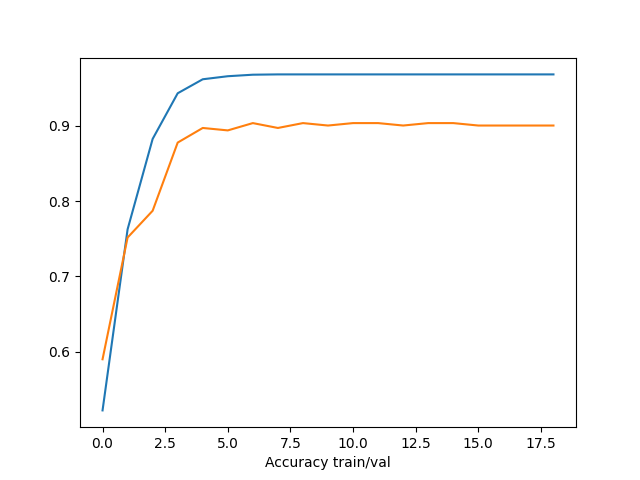

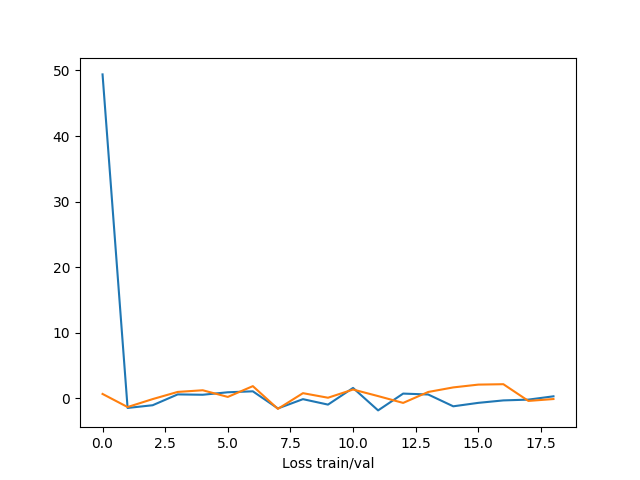

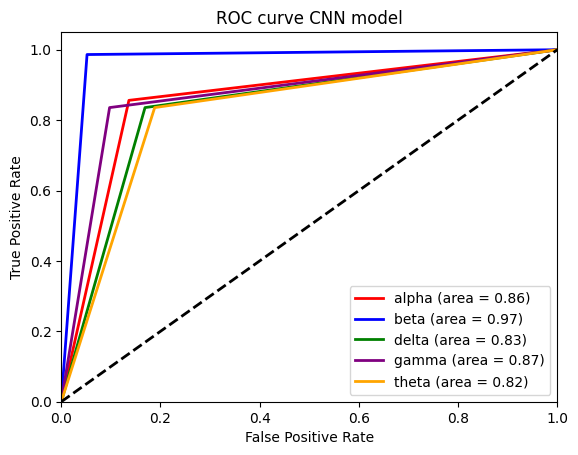

In [7]:
metrics = model.metrics_show()
# best_mn = metrics[metrics['Dataset'] == 'Necker cube'].sort_values(by='Test Accuracy', ascending=False).iloc[0]
best_mn = metrics.sort_values(by='Test Accuracy', ascending=False).iloc[0]
print('Best model')
print(best_mn, '\n')
dir = f'{LOG_DIR}{best_mn.iloc[0]}_{best_mn.iloc[1].replace(' ', '_')}_{best_mn.iloc[2]}_{best_mn.iloc[3]}/'

print('Classification report')
classification_report_file = f'{dir}classification_report.pkl'
with open(classification_report_file, 'rb') as f:
    loaded_report = pickle.load(f)
report_df = pd.DataFrame(loaded_report).transpose()
print(report_df, '\n')

accuracy_file = f'{dir}accuracy.png'
display(IPImage(filename=accuracy_file))

loss_file = f'{dir}loss.png'
display(IPImage(filename=loss_file))

fpr = {}
tpr = {}
roc_auc = {}
i = 0

for rhythm in Config.RHYTHMS:
    
    dir = f'{LOG_DIR}{best_mn.iloc[0]}_{best_mn.iloc[1].replace(' ', '_')}_{rhythm}_{best_mn.iloc[3]}/'
    roc_auc_pred_file = f'{dir}roc_pred.pkl'
    roc_auc_true_file = f'{dir}roc_true_dump.pkl'
    with open(roc_auc_pred_file, 'rb') as f:
        roc_auc_pred = pickle.load(f)
    with open(roc_auc_true_file, 'rb') as f:
        roc_auc_true = pickle.load(f)    
    targets_pred = roc_auc_pred
    targets_true = roc_auc_true
    fpr[i], tpr[i], _ = roc_curve(targets_true, targets_pred)
    roc_auc[i] = roc_auc_score(targets_true, targets_pred)
    i = i+1

plt.figure()
colors = ['red', 'blue', 'green', 'purple', 'orange']
for i, color in zip(range(len(roc_auc)), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='{0} (area = {1:0.2f})'
                   ''.format(Config.RHYTHMS[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC curve {best_mn.iloc[0]} model')
plt.legend(loc="lower right")
plt.show()

# Shap

In [8]:
best_model_1 = metrics.sort_values(by='Test Accuracy', ascending=False).iloc[0]
best_model_2 = metrics[metrics['Model'] != best_model_1.Model].sort_values(by='Test Accuracy', ascending=False).iloc[0]
best_model_3 = metrics[(metrics['Model'] != best_model_1.Model) & (metrics['Model'] != best_model_2.Model)].sort_values(by='Test Accuracy', ascending=False).iloc[0]

In [9]:
from datasets import Dataset, DatasetDict, load_from_disk

def shap_explainer(best_model: str):
    print(best_model)
    shap_ds = DATASET[best_model['Rhythm']].to_pandas()

    def average_columns(df, n):
        num_new_columns = df.shape[1] // n
        averaged_df = pd.DataFrame(index=df.index)
        df = df.astype(float)
        
        for i in range(num_new_columns):
            start_col = i * n
            end_col = start_col + n
            averaged_df[f'{i+1}s'] = df.iloc[:, start_col:end_col].mean(axis=1)
        
        return averaged_df

    df1 = shap_ds.iloc[:, 0:7]
    df2 = average_columns(shap_ds.iloc[:, 7:-1], 250)
    shap_df = pd.concat([df1, df2], axis=1)
    DATASET['shap'] = Dataset.from_pandas(shap_df)
    # DATASET['shap'].to_pandas()

    if best_model['Model'] == 'CNN':
        Config.in_features = 896
        # Config.out_features = 896
    else:    
        Config.in_features = 60
        Config.out_features = 12100
    model = RobiulModel(model_name=best_model['Model'], dataset=DATASET, experiment=best_model['Dataset'], rhythm='shap', optimizer=best_model['Optimizer'], in_features=Config.in_features, out_features=Config.out_features)
    model.fit()
    # model.test()
    shap_ds = CustomDataset(dataset=DATASET, experiment=best_model['Dataset'], signal='shap')
    X_train = shap_ds.df_train
    X_test = shap_ds.df_test
    
    model.shap_mode = True

    explainer = shap.Explainer(model, X_train) # max_evals=X_train.shape[1]*2+1)
    shap_values = explainer(X_test)


    if best_model['Model'] == 'CNN':
        shap.summary_plot(shap_values.mean(2), X_test)
    else:
        shap.summary_plot(shap_values, X_test)

In [10]:
shap_explainer(best_model_1)

Model                   CNN
Dataset           Mona Lisa
Rhythm                 beta
Optimizer            Adamax
Start LR              0.001
Finish LR             0.001
Epoch                     9
Train Accuracy     0.967742
Val Accuracy       0.903226
Test Accuracy      0.935484
Train Time             54.2
Inference Time         1.69
ROC AUC            0.967177
Name: 82, dtype: object


Epoch: [1/200] | train_loss = [0.6676] : train_acc = [0.5351] : val_loss = [0.6517] : val_acc = [0.5613] : lr = [0.001]


Epoch: [2/200] | train_loss = [0.6552] : train_acc = [0.5496] : val_loss = [0.6396] : val_acc = [0.5581] : lr = [0.001]
Find best loss=[0.6516803656854937], model saved on 2 epoch


Epoch: [3/200] | train_loss = [0.6454] : train_acc = [0.5621] : val_loss = [0.6331] : val_acc = [0.5645] : lr = [0.001]
Find best loss=[0.6395911401317965], model saved on 3 epoch


Epoch: [4/200] | train_loss = [0.6401] : train_acc = [0.5802] : val_loss = [0.6277] : val_acc = [0.5452] : lr = [0.001]
Find best loss=[0.6330890040243825], model saved on 4 epoch


...

Epoch: [13/200] | train_loss = [0.5835] : train_acc = [0.6613] : val_loss = [0.6014] : val_acc = [0.6161] : lr = [0.001]
Find best loss=[0.6064359987935712], model saved on 13 epoch


Epoch: [14/200] | train_loss = [0.5740] : train_acc = [0.6625] : val_loss = [0.5950] : val_acc = [0.6194] : lr = [0.001]
Find best loss=[0.6014230751222179], model saved on 14 epoch


Epoch: [15/200] | train_loss = [0.5628] : train_acc = [0.6738] : val_loss = [0.5968] : val_acc = [0.6226] : lr = [0.001]


Epoch: [16/200] | train_loss = [0.5511] : train_acc = [0.6718] : val_loss = [0.5889] : val_acc = [0.6355] : lr = [0.001]
Find best loss=[0.5949675267742526], model saved on 16 epoch


Epoch: [17/200]:   4%|▍         | 1/24 [00:01<00:28,  1.26s/it]

Model                   Big
Dataset           Mona Lisa
Rhythm                gamma
Optimizer          Adadelta
Start LR               0.01
Finish LR             0.001
Epoch                   115
Train Accuracy     0.967742
Val Accuracy       0.912903
Test Accuracy      0.922581
Train Time           629.04
Inference Time         1.63
ROC AUC            0.987591
Name: 21, dtype: object


Epoch: [1/200] | train_loss = [215.9848] : train_acc = [0.5355] : val_loss = [216.8186] : val_acc = [0.4710] : lr = [0.01]


Epoch: [2/200] | train_loss = [213.6609] : train_acc = [0.6649] : val_loss = [216.1259] : val_acc = [0.5774] : lr = [0.01]
Find best loss=[216.81856216922884], model saved on 2 epoch


Epoch: [3/200] | train_loss = [210.8987] : train_acc = [0.7310] : val_loss = [214.7085] : val_acc = [0.6484] : lr = [0.01]
Find best loss=[216.12586728988154], model saved on 3 epoch


Epoch: [4/200] | train_loss = [210.2901] : train_acc = [0.7794] : val_loss = [214.3443] : val_acc = [0.6774] : lr = [0.01]
Find best loss=[214.70846360729587], model saved on 4 epoch


...

Epoch: [83/200] | train_loss = [198.2125] : train_acc = [0.9669] : val_loss = [206.4482] : val_acc = [0.8129] : lr = [0.001]


Epoch: [84/200] | train_loss = [197.4054] : train_acc = [0.9673] : val_loss = [206.3056] : val_acc = [0.8129] : lr = [0.001]


Epoch: [85/200] | train_loss = [197.5380] : train_acc = [0.9665] : val_loss = [206.4297] : val_acc = [0.8032] : lr = [0.001]


Epoch: [86/200] | train_loss = [198.7401] : train_acc = [0.9673] : val_loss = [206.2761] : val_acc = [0.8161] : lr = [0.001]
 Finished on 86 epoch. 


PermutationExplainer explainer: 311it [03:12,  1.55it/s]                         


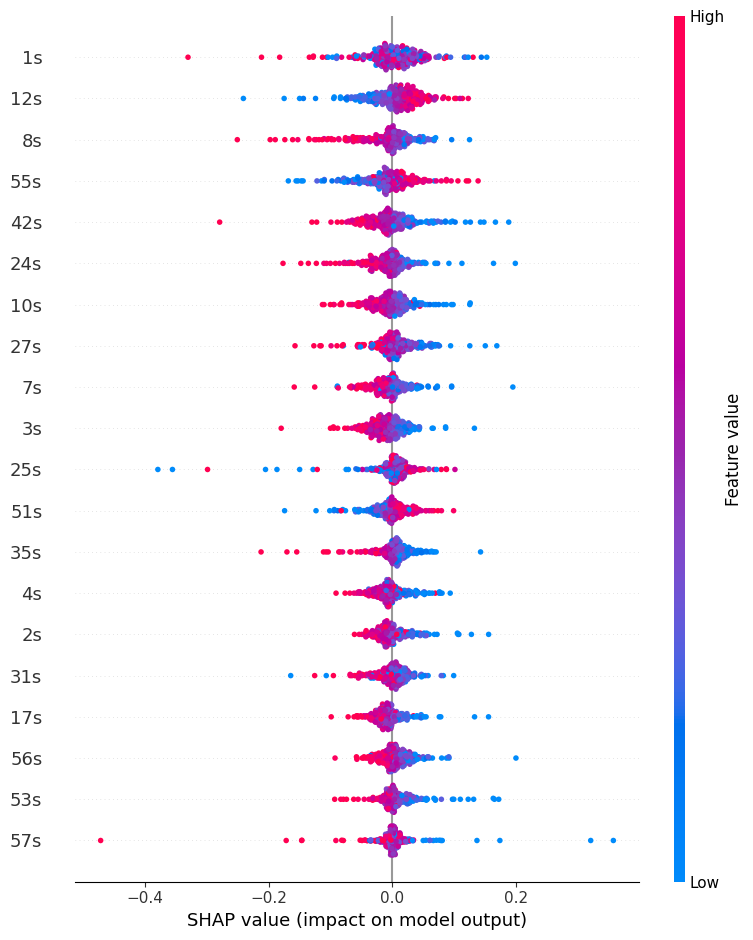

In [10]:
shap_explainer(best_model_2)

Model                 Small
Dataset           Mona Lisa
Rhythm                 beta
Optimizer             NAdam
Start LR            0.00001
Finish LR           0.00001
Epoch                    27
Train Accuracy     0.954839
Val Accuracy       0.912903
Test Accuracy      0.919355
Train Time           144.07
Inference Time         1.75
ROC AUC            0.988748
Name: 154, dtype: object


Epoch: [1/200] | train_loss = [216.2671] : train_acc = [0.5218] : val_loss = [216.1757] : val_acc = [0.5226] : lr = [1e-05]


Epoch: [2/200] | train_loss = [214.9207] : train_acc = [0.5847] : val_loss = [215.1924] : val_acc = [0.5935] : lr = [1e-05]
Find best loss=[216.17574384135585], model saved on 2 epoch


Epoch: [3/200] | train_loss = [212.8436] : train_acc = [0.6165] : val_loss = [214.8539] : val_acc = [0.6129] : lr = [1e-05]
Find best loss=[215.19238871912802], model saved on 3 epoch


Epoch: [4/200] | train_loss = [212.5123] : train_acc = [0.6294] : val_loss = [214.5413] : val_acc = [0.6194] : lr = [1e-05]
Find best loss=[214.85388971144152], model saved on 4 epoch


...

Epoch: [85/200] | train_loss = [203.1826] : train_acc = [0.9343] : val_loss = [210.7065] : val_acc = [0.7839] : lr = [1.0000000000000004e-08]


Epoch: [86/200] | train_loss = [204.4103] : train_acc = [0.9379] : val_loss = [210.5023] : val_acc = [0.7839] : lr = [1.0000000000000004e-08]


Epoch: [87/200] | train_loss = [205.5677] : train_acc = [0.9363] : val_loss = [210.7285] : val_acc = [0.7774] : lr = [1.0000000000000004e-08]


Epoch: [88/200] | train_loss = [203.6766] : train_acc = [0.9387] : val_loss = [210.7331] : val_acc = [0.7774] : lr = [1.0000000000000004e-08]
 Finished on 88 epoch. 


PermutationExplainer explainer: 311it [00:43,  5.45it/s]                         


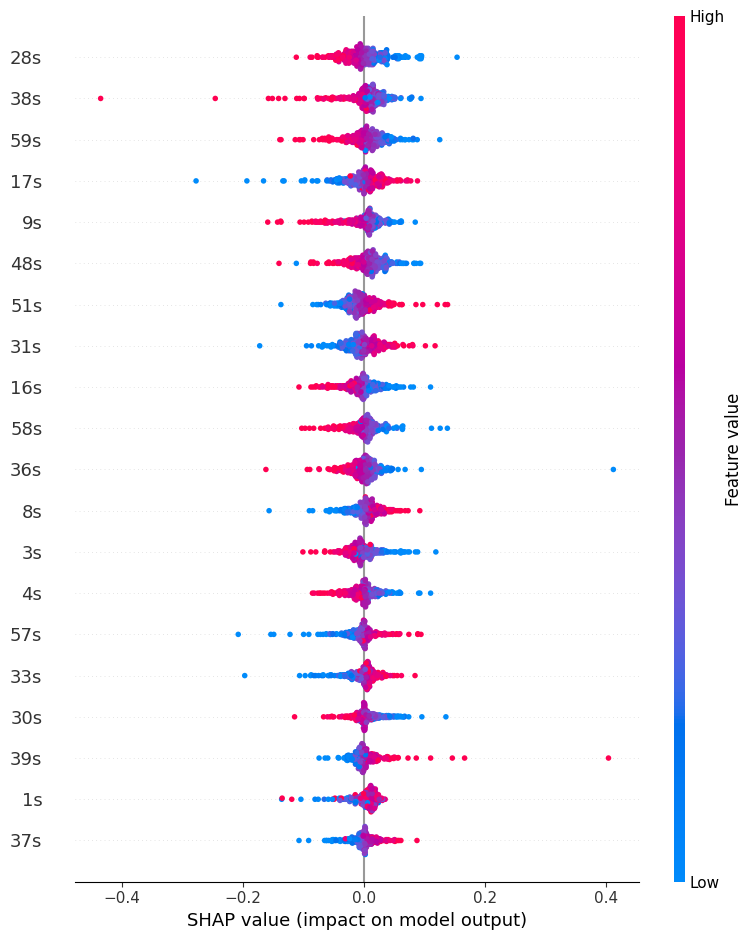

In [11]:
shap_explainer(best_model_3)